### Notebook
- **Name:** `cs_wind_spans.ipynb`
- **Created/updated:** 2026-02-27
- **Python:** 3.x

### Purpose
Compute wind metrics along spans (between supports) using WindNinja/meteorological data.

### Inputs
Supports/spans definition, WindNinja wind fields, and configuration parameters.

### Outputs
Per-span wind metrics tables and any derived GIS layers.

### Dependencies
- (see imports below)

### Usage
Executed by the project pipeline (e.g., via Papermill) or run interactively in Jupyter.

### Notes
- Keep paths and parameters centralized in `config.toml` / `CONFIG_PATH` where applicable.


In [1]:
# Parameters (Papermill)
CONFIG_PATH = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml" # "config.toml" #"config.toml"
PROJECT_ROOT = r"E:\mario\python\criticalspam"

### Wind in spans


In [2]:
import sys
print(sys.version)
print(sys.executable)

3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]
c:\Python\Python312\python.exe


In [3]:
from __future__ import annotations  # Enables postponed evaluation of type annotations (PEP 563/PEP 649 behavior)

# Standard library: data classes, filesystem paths, combinatorics, math,
# regular expressions, system utilities, type hints, and TOML parsing.
from dataclasses import dataclass      # Provides decorator for creating data classes (structured objects)
from itertools import combinations    # Generates combinations of elements (combinatorics)
import math                           # Mathematical functions (factorials, combinatorics, etc.)
from pathlib import Path              # Object-oriented filesystem paths handling
import re                             # Regular expressions for pattern matching in strings
import sys                            # Access to Python runtime system (arguments, exit, etc.)
import tomllib                        # Reads TOML configuration files (Python 3.11+)
from typing import List, Optional, Tuple  # Type hints for lists, optional values, and tuples

# Third-party libraries: numerical computing, tabular/GIS data handling,
# coordinate reference systems, raster access, plotting, and geometric operations.
import geopandas as gpd               # Geospatial data structures and operations (GeoDataFrame)
import matplotlib as mpl              # Core Matplotlib configuration and styling
import matplotlib.pyplot as plt       # Plotting interface for creating figures and charts
import numpy as np                    # Numerical computing with arrays and vectorized operations
import pandas as pd                   # Tabular data manipulation and analysis (DataFrame)
import rasterio                       # Reading and writing raster geospatial data (e.g., GeoTIFF)
from pyproj import CRS                # Coordinate Reference System definitions and transformations
from shapely import line_interpolate_point, line_locate_point  # Linear referencing on geometries
from shapely.geometry import LineString, MultiLineString, Point  # Geometric primitives (lines, points)

In [4]:
# Ruta al directorio raíz del proyecto (sube 1 nivel desde notebooks/)
#ROOT = Path.cwd().resolve().parent
#print(f"Project root: {ROOT}")

# Añade src/ al path de importación
SRC = PROJECT_ROOT + r"\src"
print(f"Adding to sys.path: {SRC}")

# Imprimer CONFIG_PATH para verificar que es correcto
print(f"Using config path: {CONFIG_PATH}")

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Ya puedes importar
from cs_utils import Config, join_base, load_config_toml

Adding to sys.path: E:\mario\python\criticalspam\src
Using config path: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml


In [5]:
cfg = load_config_toml(CONFIG_PATH)

print("cs_wind_spans.ipynb")
print("Config path:", CONFIG_PATH)

cs_wind_spans.ipynb
Config path: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml


In [6]:


def read_points_from_shp(
    shp_path: str | Path,
    source_epsg: Optional[int] = 25830,
    to_epsg: int | None = None,
    keep_cols: list[str] | None = None,
    rename: dict[str, str] | None = None,
    x_col: str = "apoyoUTMx",
    y_col: str = "apoyoUTMy",
    geometry_as_midpoint_xy: bool = True,
) -> pd.DataFrame:
    """
    Lee un shapefile (.shp) de puntos (pueden ser apoyos, vanos, etc.) y devuelve un DataFrame.

    Parámetros
    ----------
    shp_path : ruta al .shp
    to_epsg  : si se indica, reproyecta a EPSG:to_epsg antes de extraer coordenadas
    keep_cols: columnas a conservar (si None, conserva todas)
    rename   : diccionario para renombrar columnas (p.ej. {"VANO_X":"vanoUTMx","VANO_Y":"vanoUTMy"})
    x_col, y_col : nombres finales deseados para coordenadas del punto medio
    geometry_as_midpoint_xy : si True, toma x/y desde la geometría (recomendado)

    Devuelve
    --------
    pandas.DataFrame con atributos + vanoUTMx/vanoUTMy (si geometry_as_midpoint_xy=True).
    """
    import geopandas as gpd

    shp_path = Path(shp_path)
    if not shp_path.exists():
        raise FileNotFoundError(shp_path)

    gdf = gpd.read_file(shp_path)

    # Renombrado temprano (útil por nombres truncados del Shapefile)
    if rename:
        gdf = gdf.rename(columns=rename)

   # 1. Asignar CRS si falta
    if gdf.crs is None:
        print(f"CRS no definido → asignando EPSG:{source_epsg}")
        gdf = gdf.set_crs(epsg=source_epsg)

    # 2. Reproyección
    if to_epsg is not None:
        gdf = gdf.to_crs(epsg=int(to_epsg))

  

    # Extraer coordenadas desde la geometría (puntos)
    if geometry_as_midpoint_xy:
        if not all(gdf.geometry.geom_type == "Point"):
            raise ValueError("El shapefile no contiene geometrías Point. Ajusta geometry_as_midpoint_xy o revisa el .shp.")
        gdf[x_col] = gdf.geometry.x.astype(float)
        gdf[y_col] = gdf.geometry.y.astype(float)
    else:
        # En este modo exigimos que existan campos x_col/y_col ya en atributos
        if x_col not in gdf.columns or y_col not in gdf.columns:
            raise KeyError(f"No existen columnas {x_col}/{y_col} y geometry_as_midpoint_xy=False.")

    # Selección de columnas
    if keep_cols is not None:
        cols = list(keep_cols)
        # asegura que las coordenadas estén
        if x_col not in cols: cols.append(x_col)
        if y_col not in cols: cols.append(y_col)

        missing = [c for c in cols if c not in gdf.columns]
        if missing:
            raise KeyError(f"Columnas no encontradas en el shapefile: {missing}")

        gdf = gdf.loc[:, cols + ["geometry"]] if "geometry" in gdf.columns else gdf.loc[:, cols]

    # Devolver DataFrame (sin geometría)
    return pd.DataFrame(gdf.drop(columns="geometry"))


In [7]:
gdf = gpd.read_file(cfg.out_apoyos_shp)
gdf.head()

,Number,Station,X,Y,Z,Line angle,Structure,MAT,geometry
0,1,NaN,257521932,4808272963,107672,NaN,Pórtico Corredoria,Pórtico Corredoria,POINT Z (257521.932 4808272.963 107.672)
1,2,186270.0,257702460,4808318851,115947,0.0197,AP111280,AP111280,POINT Z (257702.460 4808318.851 115.947)
2,3,551326.0,258056294,4808408674,100068,0.0783,AP300628,AP300628,POINT Z (258056.294 4808408.674 100.068)
3,4,941933.0,258435010,4808504318,105202,243858.0000,AP300627,AP300627,POINT Z (258435.010 4808504.318 105.202)
4,5,1118486.0,258609941,4808480437,86685,0.2709,AP300626,AP300626,POINT Z (258609.941 4808480.437 86.685)


In [8]:
apoyos_df = read_points_from_shp(
    cfg.out_apoyos_shp,
    source_epsg=25830,
    to_epsg=25830,
    x_col="UTMx",
    y_col="UTMy",
    rename={"X": "UTMx", "Y": "UTMy"},
    keep_cols=["MAT", "Structure", "Number"]
)

CRS no definido → asignando EPSG:25830


In [9]:
apoyos_df.head()  

,MAT,Structure,Number,UTMx,UTMy
0,Pórtico Corredoria,Pórtico Corredoria,1,257521.932,4808272.963
1,AP111280,AP111280,2,257702.460,4808318.851
2,AP300628,AP300628,3,258056.294,4808408.674
3,AP300627,AP300627,4,258435.010,4808504.318
4,AP300626,AP300626,5,258609.941,4808480.437


Obtener coordenadas UTM x e y de los puntos de muestreo espacial sobre la línea. El número de puntos está ligado al mesh_resolution definido para WindNinja

In [10]:
# Configuración
base = Path( cfg.general_path )
SHAPEFILE_PATH = join_base(base, cfg.in_shp)
STEP_METERS = cfg.mesh_resolution 
OUTPUT_CSV = join_base(base, "puntos_linea.csv")
OUTPUT_XLSX = join_base(base, "puntos_linea.xlsx")
print(f"SHAPEFILE_PATH: {SHAPEFILE_PATH}")
print(f"STEP_METERS: {STEP_METERS}")    
print(f"OUTPUT_CSV: {OUTPUT_CSV}")
print(f"OUTPUT_XLSX: {OUTPUT_XLSX}")

SHAPEFILE_PATH: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\Corredoria_Grado_1_y_2\Corredoria-Grado.shp
STEP_METERS: 25.0
OUTPUT_CSV: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\puntos_linea.csv
OUTPUT_XLSX: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\puntos_linea.xlsx


In [11]:
# Traza de la línea a partir de los apoyos ordenados
coords = list(zip(apoyos_df["UTMx"], apoyos_df["UTMy"]))
line = LineString(coords)

print("Longitud [m]:", line.length)

Longitud [m]: 13703.944259909065


In [12]:
# muestrea la traza de la línea en pasos de step_m metros
def sample_line(line, step_m):
    distances = np.arange(0, line.length, step_m)
    distances = np.append(distances, line.length)

    points = [line_interpolate_point(line, d) for d in distances]

    return [(p.x, p.y) for p in points]

In [13]:
puntos_muestreados = sample_line(line, STEP_METERS)
puntos_df = pd.DataFrame(puntos_muestreados, columns=["UTMx", "UTMy"])
puntos_df.to_csv(OUTPUT_CSV, index=False)

In [14]:
# puntos muestreados de la traza de la linea
puntos_df

,UTMx,UTMy
0,257521.932000,4.808273e+06
1,257546.161500,4.808279e+06
2,257570.391000,4.808285e+06
3,257594.620500,4.808291e+06
4,257618.850000,4.808298e+06
...,...,...
545,270726.793919,4.807223e+06
546,270746.710529,4.807207e+06
547,270766.627139,4.807192e+06
548,270786.543749,4.807177e+06


In [15]:

# incorpora a cada tramo entre apoyos la dirección de dicho tramo considerando el norte
def add_bearing_from_north(df, x_col="UTMx", y_col="UTMy", out_col="dir_deg"):
    df = df.copy()

    # Punto siguiente
    dx = (-1)*(df[x_col].shift(-1) - df[x_col]) # -1 porque UTMx avanza del este hacia el oeste
    dy = df[y_col].shift(-1) - df[y_col]

    # Ángulo respecto al norte, sentido horario
    ang_deg = np.degrees(np.arctan2(dx, dy))
    ang_deg = (ang_deg + 360) % 360

    # Para el último punto, mantener la dirección del anterior
    if len(df) >= 2:
        ang_deg.iloc[-1] = ang_deg.iloc[-2]
    elif len(df) == 1:
        ang_deg.iloc[0] = np.nan

    df[out_col] = ang_deg
    return df

          UTMx          UTMy   direccion  Number
0  257521.9320  4.808273e+06  284.261844       1
1  257546.1615  4.808279e+06  284.261844       2
2  257570.3910  4.808285e+06  284.261844       3
3  257594.6205  4.808291e+06  284.261844       4
4  257618.8500  4.808298e+06  284.261844       5


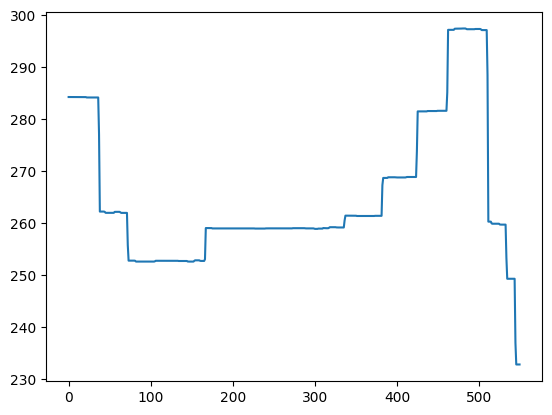

In [16]:
puntos_df = add_bearing_from_north(puntos_df, x_col="UTMx", y_col="UTMy", out_col="direccion")
puntos_df["Number"] = puntos_df.index + 1
print(puntos_df.head())

plt.plot( puntos_df["direccion"])

In [17]:
base = Path(cfg.general_path)
print(f"Base path: {base}")


path_puntos_csv = join_base( base, r"Calculos\puntos_muestreo.csv")
path_apoyos_csv = join_base( base, r"Calculos\apoyos.csv")

print(f"Saving puntos_df to: {path_puntos_csv}")
print(f"Saving apoyos_df to: {path_apoyos_csv}")


puntos_df.to_csv(path_puntos_csv, index=False, encoding="utf-8")
apoyos_df.to_csv(path_apoyos_csv, index=False, encoding="utf-8")

Base path: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2
Saving puntos_df to: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\Calculos\puntos_muestreo.csv
Saving apoyos_df to: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\Calculos\apoyos.csv


In [18]:
def sample_windninja_asc_at_points(
    vanos_df: pd.DataFrame,
    speed_asc: str | Path,
    dir_asc: str | Path,
    prj_path: str | Path | None = None,
    points_epsg: int = 25830,
    x_col: str = "UTMx",
    y_col: str = "UTMy",
    keep_cols: list[str] | None = None,
) -> pd.DataFrame:
    """
    Extrae (sample) velocidad y dirección de viento de WindNinja (ASCII Grid .asc) en los puntos intermedios de vano.

    - speed_asc: ráster ASCII de magnitud (m/s típicamente)
    - dir_asc:   ráster ASCII de dirección (grados; normalmente convención meteorológica)
    - prj_path:  fichero .prj con WKT del CRS (si los .asc no traen CRS). Si None, intenta inferirlo.
    - points_epsg: CRS de las coordenadas de los puntos (p.ej. 25830)
    """


    speed_asc = Path(speed_asc)
    dir_asc = Path(dir_asc)

    df = vanos_df.copy()
    df = df.dropna(subset=[x_col, y_col]).reset_index(drop=True)

    if keep_cols is not None:
        cols = list(keep_cols)
        if x_col not in cols: cols.append(x_col)
        if y_col not in cols: cols.append(y_col)
        missing = [c for c in cols if c not in df.columns]
        if missing:
            raise KeyError(f"Columnas no encontradas en vanos_df: {missing}")
        df = df.loc[:, cols]

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[x_col].astype(float), df[y_col].astype(float)),
        crs=f"EPSG:{int(points_epsg)}",
    )

    # CRS desde .prj (WKT), si se proporciona
    prj_crs = None
    if prj_path is not None:
        prj_path = Path(prj_path)
        wkt = prj_path.read_text(encoding="utf-8", errors="ignore")
        prj_crs = CRS.from_wkt(wkt)

    with rasterio.open(speed_asc) as src_spd, rasterio.open(dir_asc) as src_dir:
        # Validación mínima de rejilla
        if (src_spd.transform != src_dir.transform) or (src_spd.width != src_dir.width) or (src_spd.height != src_dir.height):
            raise ValueError("Los .asc de velocidad y dirección no están en la misma rejilla (transform/size).")

        # Determinar CRS efectivo del ráster
        raster_crs = src_spd.crs
        if raster_crs is None and prj_crs is not None:
            raster_crs = prj_crs
        if raster_crs is None:
            raise ValueError(
                "No se pudo determinar el CRS del ráster (.asc no trae CRS y no se proporcionó .prj)."
            )

        # Reproyectar puntos al CRS del ráster si hace falta
        if gdf.crs != raster_crs:
            gdf_r = gdf.to_crs(raster_crs)
        else:
            gdf_r = gdf

        coords = [(geom.x, geom.y) for geom in gdf_r.geometry]

        spd_vals = np.array([v[0] for v in src_spd.sample(coords)], dtype=float)
        dir_vals = np.array([v[0] for v in src_dir.sample(coords)], dtype=float)

        spd_nodata = src_spd.nodata
        dir_nodata = src_dir.nodata

    out = gdf.drop(columns="geometry").copy()
    out["wind_speed"] = spd_vals
    out["wind_dir"] = dir_vals

    # NoData -> NaN (robusto ante nodata definido en cabecera ASCII)
    if spd_nodata is not None:
        m = np.isclose(out["wind_speed"], float(spd_nodata))
        out.loc[m, "wind_speed"] = np.nan
    if dir_nodata is not None:
        m = np.isclose(out["wind_dir"], float(dir_nodata))
        out.loc[m, "wind_dir"] = np.nan

    return out


In [19]:

def add_effective_wind_projection_on_span(
    df: pd.DataFrame,
    span_dir_col: str = "direccion",      # dirección del vano (deg, 0=N, horario)
    wind_dir_col: str = "wind_dir",       # dirección del viento (deg, 0=N, horario; puede ser "from" meteorológica)
    wind_speed_col: str = "wind_speed",   # magnitud del viento (m/s)
    out_angle_col: str = "alpha_eff_deg", # ángulo axial efectivo en [0,90]
    out_proj_col: str = "v_proj_eff",     # proyección efectiva (m/s) sobre el eje del vano (sin signo)
) -> pd.DataFrame:
    """
    Añade al DataFrame:
      - alpha_eff_deg: ángulo axial entre dirección de viento y eje del vano, en [0,90] grados.
      - v_proj_eff: proyección efectiva (|V|·|cos(alpha)|) sobre el eje del vano (sin signo).

    Importante:
    - El cálculo es AXIAL: no distingue entre direcciones separadas 180° (ni en viento ni en vano).
    - Por tanto, no es necesario convertir la convención meteorológica ("from") a vector ("to").
    """
    out = df.copy()

    theta_span = pd.to_numeric(out[span_dir_col], errors="coerce").to_numpy(dtype=float)
    theta_wind = pd.to_numeric(out[wind_dir_col], errors="coerce").to_numpy(dtype=float)
    v = pd.to_numeric(out[wind_speed_col], errors="coerce").to_numpy(dtype=float)

    # Diferencia angular reducida a [0,180)
    d = np.abs(theta_wind - theta_span) % 360.0
    d = np.minimum(d, 360.0 - d)           # ahora en [0,180]
    alpha_eff = np.minimum(d, 180.0 - d)   # axial -> [0,90]

    v_proj = np.abs(v * np.sin(np.deg2rad(alpha_eff)))

    out[out_angle_col] = alpha_eff
    out[out_proj_col] = v_proj
    return out


In [20]:

def list_windninja_result_pairs(folder: str | Path) -> List[Tuple[str, Path, Path, Path, Path]]:
    """
    Busca en `folder` resultados WindNinja y devuelve una lista de tuplas:

      (base_name, vel_asc, ang_asc, vel_prj, ang_prj)

    donde `base_name` es el nombre común SIN los sufijos:
      _vel.asc, _ang.asc, _vel.prj, _ang.prj

    Requisitos:
      - ficheros con patrón: <base>_vel.asc, <base>_ang.asc, <base>_vel.prj, <base>_ang.prj
      - se consideran coincidencias completas (si falta alguno, ese base se descarta).
    """
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(folder)

    # Índices por base
    vel_asc = {}
    ang_asc = {}
    vel_prj = {}
    ang_prj = {}

    for p in folder.iterdir():
        if not p.is_file():
            continue
        name = p.name

        if name.endswith("_vel.asc"):
            base = name[:-len("_vel.asc")]
            vel_asc[base] = p
        elif name.endswith("_ang.asc"):
            base = name[:-len("_ang.asc")]
            ang_asc[base] = p
        elif name.endswith("_vel.prj"):
            base = name[:-len("_vel.prj")]
            vel_prj[base] = p
        elif name.endswith("_ang.prj"):
            base = name[:-len("_ang.prj")]
            ang_prj[base] = p

    bases = sorted(set(vel_asc) & set(ang_asc) & set(vel_prj) & set(ang_prj))

    return [(b, vel_asc[b], ang_asc[b], vel_prj[b], ang_prj[b]) for b in bases]


In [21]:
pairs = list_windninja_result_pairs(cfg.out_wn_ren)
#for base, vasc, aasc, vprj, aprj in pairs:
#    print(base)

In [22]:
def parse_windninja_dir_speed_from_name(
    filename: str | Path,
    *,
    prefix_to_remove: str = "",
) -> Tuple[float, float]:
    """
    Extrae (direccion_deg, velocidad) desde un nombre que contiene el patrón:
      DDD_d_VV_v
    (3 dígitos dir entera, 1 dígito dir decimal, 2 dígitos vel entera, 1 dígito vel decimal),
    separado por '_' y en ese orden.

    El patrón puede aparecer tras un prefijo (opcional) y puede haber más texto después.
    """
    s = Path(filename).name.strip()

    if prefix_to_remove:
        # elimina primera ocurrencia del prefijo (más robusto que startswith)
        if prefix_to_remove in s:
            s = s.replace(prefix_to_remove, "", 1)
        else:
            raise ValueError(f"No se encontró el prefijo '{prefix_to_remove}' en '{Path(filename).name}'.")

    # Buscar el patrón en cualquier parte
    m = re.search(r"(?P<dir_i>\d{3})_(?P<dir_d>\d)_(?P<spd_i>\d{2})_(?P<spd_d>\d)", s)
    if not m:
        raise ValueError(
            f"No se pudo extraer dirección/velocidad de '{Path(filename).name}'. "
            "Se esperaba encontrar: DDD_d_VV_v (p.ej. 270_3_12_5)."
        )

    dir_deg = float(f"{m.group('dir_i')}.{m.group('dir_d')}")
    spd = float(f"{m.group('spd_i')}.{m.group('spd_d')}")
    return dir_deg, spd



In [23]:
def build_all_cases_wind_effective_df(
    pairs,
    puntos_analisis_df,
    *,
    prefix_to_remove: str,
    points_epsg: int,
    keep_cols=None,
    # columnas existentes
    span_dir_col: str = "direccion",
    # nombres de salida
    case_col: str = "case",
    out_dir_col: str = "d_applied_deg",
    out_spd_col: str = "v_applied",
    # salida de efectivos
    out_angle_col: str = "alpha_eff_deg",
    out_perp_col: str = "v_perp",
    out_par_col: str = "v_par",
) -> pd.DataFrame:
    """
    Itera sobre `pairs` = [(base, vel_asc, ang_asc, vel_prj, ang_prj), ...],
    muestrea viento en puntos de vano y calcula:
      - alpha_eff_deg: ángulo axial efectivo entre eje de vano y eje de viento (0..90)
      - v_perp: componente transversal (refrigeración) = V*sin(alpha_eff)
      - v_par:  componente paralela = V*cos(alpha_eff)

    Añade a cada fila:
      - case (base)
      - d_applied_deg, v_applied: parámetros de simulación extraídos del nombre del caso
    """
    out_list = []

    for base, vasc, aasc, vprj, aprj in pairs:
        # 1) dirección/velocidad "aplicadas" (del nombre)
        d_applied, v_applied = parse_windninja_dir_speed_from_name(
            base, prefix_to_remove=prefix_to_remove
        )

        # 2) muestreo de WindNinja en puntos de vanos (usa los .asc/.prj del caso)
        df_w = sample_windninja_asc_at_points(
            puntos_analisis_df,
            speed_asc=vasc,
            dir_asc=aasc,
            prj_path=vprj,            # normalmente basta con uno
            points_epsg=points_epsg,
            keep_cols=keep_cols,
        )

        # 3) cálculo axial efectivo (sin sentido) + componentes
        theta_span = pd.to_numeric(df_w[span_dir_col], errors="coerce").to_numpy(dtype=float)
        theta_wind = pd.to_numeric(df_w["wind_dir"], errors="coerce").to_numpy(dtype=float)
        V = pd.to_numeric(df_w["wind_speed"], errors="coerce").to_numpy(dtype=float)

        d = np.abs(theta_wind - theta_span) % 360.0
        d = np.minimum(d, 360.0 - d)          # [0,180]
        alpha_eff = np.minimum(d, 180.0 - d)  # axial -> [0,90]
        a = np.deg2rad(alpha_eff)

        df_w[out_angle_col] = alpha_eff
        df_w[out_perp_col] = np.abs(V * np.sin(a))  # transversal (refrigeración)
        df_w[out_par_col]  = np.abs(V * np.cos(a))  # paralela

        # 4) columnas del caso
        df_w[case_col] = base
        df_w[out_dir_col] = d_applied
        df_w[out_spd_col] = v_applied

        out_list.append(df_w)

    if not out_list:
        return pd.DataFrame()

    return pd.concat(out_list, ignore_index=True)



In [24]:
df_all_puntos = build_all_cases_wind_effective_df(
    pairs=pairs,
    puntos_analisis_df=puntos_df,
    prefix_to_remove="Corredoria_Grado_1_y_2_",
    points_epsg=cfg.apoyos_epsg_arg,
    keep_cols=["direccion", "UTMx", "UTMy", "Number"] #["MAT", "distancia", "direccion", "vanoUTMx", "vanoUTMy"],
)

print(df_all_puntos.shape)
print(df_all_puntos.columns)
df_all_puntos.head()


(198000, 12)
Index(['direccion', 'UTMx', 'UTMy', 'Number', 'wind_speed', 'wind_dir',
       'alpha_eff_deg', 'v_perp', 'v_par', 'case', 'd_applied_deg',
       'v_applied'],
      dtype='object')


,direccion,UTMx,UTMy,Number,wind_speed,wind_dir,alpha_eff_deg,v_perp,v_par,case,d_applied_deg,v_applied
0,284.261844,257521.9320,4.808273e+06,1,0.84,2.0,77.738156,0.820837,0.178399,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
1,284.261844,257546.1615,4.808279e+06,2,0.89,4.0,79.738156,0.875763,0.158551,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
2,284.261844,257570.3910,4.808285e+06,3,0.91,4.0,79.738156,0.895444,0.162114,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
3,284.261844,257594.6205,4.808291e+06,4,0.93,3.0,78.738156,0.912093,0.181623,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
4,284.261844,257618.8500,4.808298e+06,5,0.95,3.0,78.738156,0.931708,0.185528,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0


In [25]:
len( apoyos_df)

57

                  MAT           Structure  Number        UTMx         UTMy  \
0  Pórtico Corredoria  Pórtico Corredoria       1  257521.932  4808272.963   
1            AP111280            AP111280       2  257702.460  4808318.851   
2            AP300628            AP300628       3  258056.294  4808408.674   
3            AP300627            AP300627       4  258435.010  4808504.318   
4            AP300626            AP300626       5  258609.941  4808480.437   

    direccion  
0  284.261844  
1  284.244008  
2  284.173567  
3  262.226225  
4  261.982596  


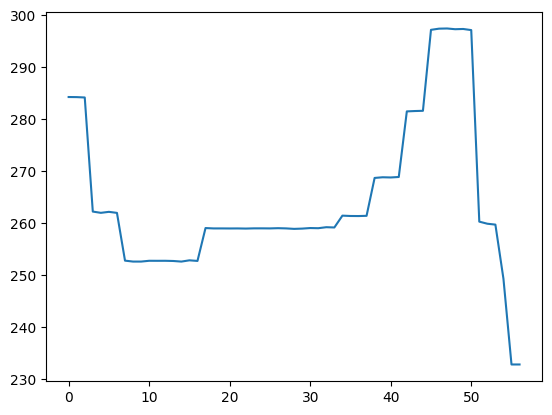

In [26]:
apoyos_df = add_bearing_from_north(apoyos_df, x_col="UTMx", y_col="UTMy", out_col="direccion")
print(apoyos_df.head())

plt.plot( apoyos_df["direccion"])


In [27]:
apoyos_df.head()

,MAT,Structure,Number,UTMx,UTMy,direccion
0,Pórtico Corredoria,Pórtico Corredoria,1,257521.932,4808272.963,284.261844
1,AP111280,AP111280,2,257702.460,4808318.851,284.244008
2,AP300628,AP300628,3,258056.294,4808408.674,284.173567
3,AP300627,AP300627,4,258435.010,4808504.318,262.226225
4,AP300626,AP300626,5,258609.941,4808480.437,261.982596


In [ ]:
df_all_apoyos = build_all_cases_wind_effective_df(
    pairs=pairs,
    puntos_analisis_df=apoyos_df,
    prefix_to_remove="Corredoria_Grado_1_y_2_",
    points_epsg=cfg.apoyos_epsg_arg,
    keep_cols=["direccion", "UTMx", "UTMy", "MAT", "Structure", "Number"] #["MAT", "distancia", "direccion", "vanoUTMx", "vanoUTMy"],
)


#df_all_apoyos.to_excel( r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\df_all_apoyos.xlsx" )

print(df_all_apoyos.shape)
print(df_all_apoyos.columns)
df_all_apoyos.head()

(20520, 14)
Index(['direccion', 'UTMx', 'UTMy', 'MAT', 'Structure', 'Number', 'wind_speed',
       'wind_dir', 'alpha_eff_deg', 'v_perp', 'v_par', 'case', 'd_applied_deg',
       'v_applied'],
      dtype='object')


,direccion,UTMx,UTMy,MAT,Structure,Number,wind_speed,wind_dir,alpha_eff_deg,v_perp,v_par,case,d_applied_deg,v_applied
0,284.261844,257521.932,4808272.963,Pórtico Corredoria,Pórtico Corredoria,1,0.84,2.0,77.738156,0.820837,0.178399,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
1,284.244008,257702.460,4808318.851,AP111280,AP111280,2,0.95,4.0,79.755992,0.934856,0.168949,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
2,284.173567,258056.294,4808408.674,AP300628,AP300628,3,0.88,356.0,71.826433,0.836102,0.274469,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
3,262.226225,258435.010,4808504.318,AP300627,AP300627,4,1.05,351.0,88.773775,1.049759,0.022470,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
4,261.982596,258609.941,4808480.437,AP300626,AP300626,5,0.94,359.0,82.982596,0.932959,0.114841,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0


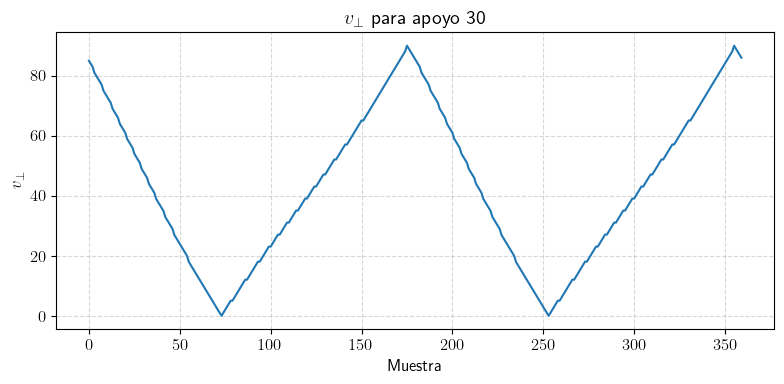

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configuración LaTeX (opcional)
mpl.rcParams.update({
    "text.usetex": True,
    "font.size": 12,
})

# Parámetro
number_sel = 30  # <-- apoyo deseado

# Filtrado
df_sel = df_all_apoyos[df_all_apoyos["Number"] == number_sel].copy()

# Plot
plt.figure(figsize=(8,4))
plt.plot(df_sel["alpha_eff_deg"].values, linestyle="-") # v_perp   

plt.xlabel(r"Muestra")
plt.ylabel(r"$v_{\perp}$")
plt.title(rf"$v_{{\perp}}$ para apoyo {number_sel}")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

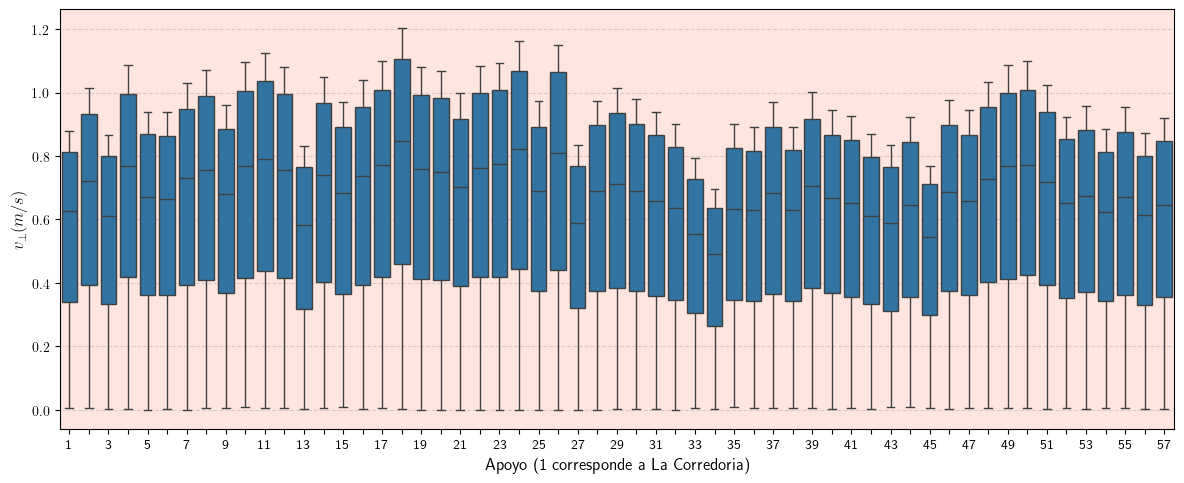

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# Configuración tipográfica (LaTeX + tamaños)
# =========================
mpl.rcParams.update({
    "text.usetex": True,          # activar LaTeX
    "font.size": 12,              # tamaño base
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# =========================
# Preparación datos
# =========================
df = df_all_apoyos.copy()
df["Number"] = df["Number"].astype(int)
df["v_perp"] = df["v_perp"].astype(float)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(12, 5))

fig.patch.set_facecolor("white")      # exterior (ticks, labels, márgenes)
ax.set_facecolor("#ffe5e0")           # interior (salmón claro)

sns.boxplot(data=df, x="Number", y="v_perp", ax=ax)

# =========================
# Reducir etiquetas eje X (1 de cada 2)
# =========================
ticks = ax.get_xticks()
labels = [int(t.get_text()) if t.get_text() != '' else '' for t in ax.get_xticklabels()]

new_labels = [str(l) if (i % 2 == 0) else '' for i, l in enumerate(labels)]
ax.set_xticks(ticks)
ax.set_xticklabels(new_labels)

# =========================
# Etiquetas y título (LaTeX)
# =========================
ax.set_xlabel(r"Apoyo (1 corresponde a La Corredoria)")
ax.set_ylabel(r"$v_{\perp} (m/s)$")
#ax.set_title(r"Distribuci\'on de $v_{\perp}$ por apoyo")

ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [31]:
df_filt = df_all_puntos[
    (df_all_puntos["Number"] == 1) 
]

df_filt

,direccion,UTMx,UTMy,Number,wind_speed,wind_dir,alpha_eff_deg,v_perp,v_par,case,d_applied_deg,v_applied
0,284.261844,257521.932,4808272.963,1,0.84,2.0,77.738156,0.820837,0.178399,Corredoria_Grado_1_y_2_000_0_01_0_01-01-2025_0000,0.0,1.0
550,284.261844,257521.932,4808272.963,1,0.85,4.0,79.738156,0.836403,0.151425,Corredoria_Grado_1_y_2_001_0_01_0_01-01-2025_0015,1.0,1.0
1100,284.261844,257521.932,4808272.963,1,0.85,5.0,80.738156,0.838919,0.136805,Corredoria_Grado_1_y_2_002_0_01_0_01-01-2025_0030,2.0,1.0
1650,284.261844,257521.932,4808272.963,1,0.85,6.0,81.738156,0.841178,0.122143,Corredoria_Grado_1_y_2_003_0_01_0_01-01-2025_0045,3.0,1.0
2200,284.261844,257521.932,4808272.963,1,0.85,7.0,82.738156,0.843182,0.107443,Corredoria_Grado_1_y_2_004_0_01_0_01-01-2025_0100,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
195250,284.261844,257521.932,4808272.963,1,0.84,356.0,71.738156,0.797693,0.263222,Corredoria_Grado_1_y_2_355_0_01_0_01-04-2025_1645,355.0,1.0
195800,284.261844,257521.932,4808272.963,1,0.84,358.0,73.738156,0.806393,0.235223,Corredoria_Grado_1_y_2_356_0_01_0_01-04-2025_1700,356.0,1.0
196350,284.261844,257521.932,4808272.963,1,0.84,359.0,74.738156,0.810376,0.221114,Corredoria_Grado_1_y_2_357_0_01_0_01-04-2025_1715,357.0,1.0
196900,284.261844,257521.932,4808272.963,1,0.84,360.0,75.738156,0.814111,0.206937,Corredoria_Grado_1_y_2_358_0_01_0_01-04-2025_1730,358.0,1.0


### Matriz $ [ \Omega e^k ] $ (eq. 5.5)

rows = sorted(df_all_puntos["d_applied_deg"].unique())
cols = sorted(df_all_puntos["Number"].unique())

M = np.full((len(rows), len(cols)), np.nan)

row_map = {v: i for i, v in enumerate(rows)}
col_map = {v: j for j, v in enumerate(cols)}

for _, r in df_all_puntos.iterrows():
    i = row_map[r["d_applied_deg"]]
    j = col_map[r["Number"]]
    M[i, j] = r["valor"]

In [32]:
Omegaek = df_all_puntos.pivot(
    index="d_applied_deg",
    columns="Number",
    values="v_perp"  
)

Omegaek.head()


Number,1,2,3,4,5,6,7,8,9,10,...,541,542,543,544,545,546,547,548,549,550
d_applied_deg,,,,,,,,,,,,,,,,,,,,,
0.0,0.820837,0.875763,0.895444,0.912093,0.931708,0.944644,0.954484,0.954513,0.934856,0.827393,...,0.839778,0.857646,0.866580,0.874054,0.764112,0.737510,0.756300,0.763940,0.763940,0.756300
1.0,0.836403,0.878397,0.898136,0.917876,0.934804,0.959933,0.959933,0.959957,0.947533,0.833685,...,0.832279,0.849987,0.867696,0.866580,0.753568,0.733544,0.745036,0.752561,0.752561,0.745036
2.0,0.838919,0.880763,0.900556,0.920348,0.937615,0.962220,0.962220,0.962240,0.952337,0.836450,...,0.833299,0.850842,0.867696,0.867696,0.761336,0.733544,0.740954,0.740954,0.740954,0.733544
3.0,0.841178,0.894630,0.912621,0.932460,0.950037,0.964213,0.974153,0.974171,0.954305,0.848831,...,0.825210,0.842583,0.859613,0.859613,0.750451,0.721830,0.729121,0.729121,0.729121,0.721830
4.0,0.843182,0.896207,0.916123,0.934392,0.952300,0.975870,0.975870,0.975886,0.965940,0.853136,...,0.825469,0.834067,0.859956,0.851269,0.739337,0.709895,0.717066,0.724236,0.729121,0.729121


In [33]:
Omegaekmin = Omegaek.min(axis=1)  # eq. 5.7

Omegaekmin.head()

d_applied_deg
0.0    0.501521
1.0    0.500034
2.0    0.498188
3.0    0.501806
4.0    0.499012
dtype: float64

In [34]:
Lk = Omegaek.idxmin(axis=1) # eq. 5.9

Lk.head()

d_applied_deg
0.0    16
1.0    16
2.0    16
3.0    16
4.0    16
dtype: int64

In [35]:
len(Lk)

360

In [36]:

# eq- 5.10
Omegaetjk = df_all_apoyos.pivot(
    index="d_applied_deg",
    columns="Number",
    values="v_perp"  
)

Omegaetjk.head()


Number,1,2,3,4,5,6,7,8,9,10,...,48,49,50,51,52,53,54,55,56,57
d_applied_deg,,,,,,,,,,,,,,,,,,,,,
0.0,0.820837,0.934856,0.836102,1.049759,0.932959,0.928870,1.017245,0.993907,0.920979,1.031618,...,0.858592,0.906663,0.963990,0.882781,0.924032,0.951117,0.878458,0.929786,0.718725,0.756300
1.0,0.836403,0.947533,0.831211,1.049992,0.930812,0.926212,1.014270,0.989039,0.916110,1.026504,...,0.863170,0.922333,0.971107,0.889230,0.918742,0.946177,0.883050,0.920761,0.707247,0.745036
2.0,0.838919,0.952337,0.839669,1.039905,0.928382,0.923271,1.010986,0.983869,0.901474,1.021077,...,0.877125,0.928471,0.977928,0.895408,0.913171,0.950454,0.872329,0.920054,0.714538,0.733544
3.0,0.841178,0.954305,0.843516,1.039502,0.925670,0.920049,1.007394,0.972633,0.896105,1.009293,...,0.881222,0.934326,0.993827,0.901314,0.916677,0.944884,0.875888,0.918888,0.702724,0.721830
4.0,0.843182,0.965940,0.847105,1.028793,0.922675,0.916547,1.003495,0.957185,0.896105,1.002938,...,0.894776,0.949390,1.000110,0.921802,0.910489,0.939026,0.869800,0.908844,0.690696,0.729121


In [37]:
m = cfg.num_sensores # número de sensores (puntos de medida) a seleccionar para el análisis de error
Napoyos = len(df_all_apoyos["Number"].unique())

print(f"m={m}, Napoyos={Napoyos}")

NC = math.comb(Napoyos, m)  
print(f"Combinaciones posibles de {Napoyos} apoyos tomados de {m} en {m}: NC={NC}")



m=1, Napoyos=57
Combinaciones posibles de 57 apoyos tomados de 1 en 1: NC=57


In [38]:


numbers = sorted(Omegaetjk.columns)   # valores de "Number"
comb_list = list(combinations(numbers, m))

NC = len(comb_list)

In [39]:
n_rows = len(Lk)
Mcomb = np.empty((n_rows, NC))

for j, comb in enumerate(comb_list):
    # seleccionar columnas de la combinación
    sub = Omegaetjk[list(comb)]
    
    # mínimo por fila dentro de la combinación
    Mcomb[:, j] = sub.min(axis=1).values

# Convertir a DataFrame si quieres mantener índices
Mcomb_df = pd.DataFrame(
    Mcomb,
    index=Omegaetjk.index,
    columns=range(NC)
)

In [40]:
Mcomb_df.head()

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
d_applied_deg,,,,,,,,,,,,,,,,,,,,,
0.0,0.820837,0.934856,0.836102,1.049759,0.932959,0.928870,1.017245,0.993907,0.920979,1.031618,...,0.858592,0.906663,0.963990,0.882781,0.924032,0.951117,0.878458,0.929786,0.718725,0.756300
1.0,0.836403,0.947533,0.831211,1.049992,0.930812,0.926212,1.014270,0.989039,0.916110,1.026504,...,0.863170,0.922333,0.971107,0.889230,0.918742,0.946177,0.883050,0.920761,0.707247,0.745036
2.0,0.838919,0.952337,0.839669,1.039905,0.928382,0.923271,1.010986,0.983869,0.901474,1.021077,...,0.877125,0.928471,0.977928,0.895408,0.913171,0.950454,0.872329,0.920054,0.714538,0.733544
3.0,0.841178,0.954305,0.843516,1.039502,0.925670,0.920049,1.007394,0.972633,0.896105,1.009293,...,0.881222,0.934326,0.993827,0.901314,0.916677,0.944884,0.875888,0.918888,0.702724,0.721830
4.0,0.843182,0.965940,0.847105,1.028793,0.922675,0.916547,1.003495,0.957185,0.896105,1.002938,...,0.894776,0.949390,1.000110,0.921802,0.910489,0.939026,0.869800,0.908844,0.690696,0.729121


In [41]:
Omegaekmin.head()

d_applied_deg
0.0    0.501521
1.0    0.500034
2.0    0.498188
3.0    0.501806
4.0    0.499012
dtype: float64

In [42]:
D = Mcomb_df.sub(Omegaekmin, axis=0)
diff_quad_min = np.sqrt((1/len(Lk))*(D ** 2).sum(axis=0))

j_best = diff_quad_min.idxmin()
err_best = diff_quad_min.loc[j_best]
comb_best = comb_list[j_best]

print("Índice mejor combinación:", j_best)
print("Error cuadrático mínimo:", err_best)
print("Combinación:", comb_best)

Índice mejor combinación: 33
Error cuadrático mínimo: 0.2701505692511486
Combinación: (34,)


In [43]:
numbers_sel = np.array(comb_best).ravel().astype(int)

MAT_seleccionadas = (
    apoyos_df
    .set_index("Number")
    .reindex(numbers_sel)["MAT"]
    .to_numpy()
)

print("Numbers seleccionados:", numbers_sel)
print("MAT de apoyos seleccionados:", MAT_seleccionadas)


Numbers seleccionados: [34]
MAT de apoyos seleccionados: ['AP300597']


In [44]:
# Representar errores

errores = (Mcomb_df.iloc[:, j_best] - Omegaekmin) 

In [45]:


def plot_hist_errores_cuadraticos(errores, bins=40, titulo=""):
    errores = np.asarray(errores, dtype=float)

    # --- configuración estética global ---
    mpl.rcParams.update({
        "figure.figsize": (9, 5.2),
        "figure.dpi": 120,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "axes.linewidth": 1.0,
        "grid.linewidth": 0.8,
        "lines.linewidth": 1.8,
        "font.family": "serif",
        "mathtext.fontset": "cm",   # Computer Modern, estilo LaTeX sin requerir usetex
    })

    fig, ax = plt.subplots()

    # Fondo
    fig.patch.set_facecolor("white")      # exterior (ticks, labels, márgenes)
    ax.set_facecolor("#ffe5e0")           # interior (salmón claro)

    # Histograma
    n, b, patches = ax.hist(
        errores,
        bins=bins,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9
    )

    # Estadísticos
    media = np.mean(errores)
    mediana = np.median(errores)
    maximo = np.max(errores)
    minimo = np.min(errores)

    ax.axvline(media, linestyle="--", linewidth=2.0, label=fr"Media = {media:.4f}")
    ax.axvline(mediana, linestyle="-.", linewidth=2.0, label=fr"Mediana = {mediana:.4f}")
    ax.axvline(maximo, linestyle=":", linewidth=2.0, label=fr"Máximo = {maximo:.4f}")
    ax.axvline(minimo, linestyle=":", linewidth=2.0, label=fr"Mínimo = {minimo:.4f}")
    

    # Títulos y etiquetas
    ax.set_title( titulo, pad=14)
    ax.set_xlabel(r"Diferencia [m/s]")
    ax.set_ylabel(r"Frecuencia")

    # Rejilla
    ax.grid(True, which="major", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    # Bordes
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    # Leyenda
    ax.legend(frameon=True, fancybox=True, framealpha=0.95)

    plt.tight_layout()
    plt.show()

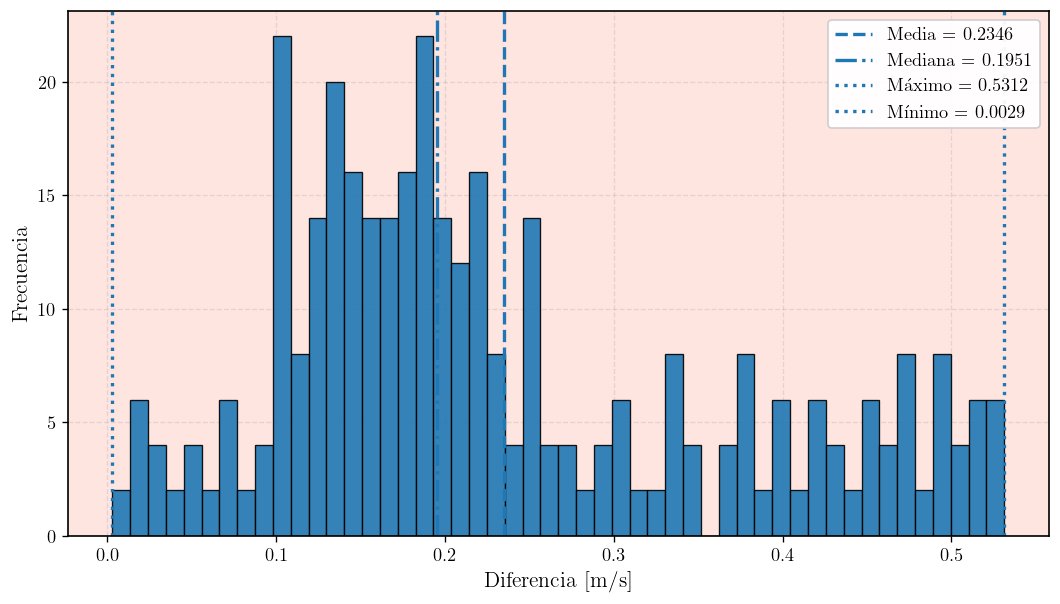

In [46]:
plot_hist_errores_cuadraticos(errores, bins=50)

In [47]:
comb_list[:5]  # primeras 5 combinaciones de apoyos (por número) tomadas de 4 en 4

[(1,), (2,), (3,), (4,), (5,)]

In [48]:
Omegaetjk[list(comb_list[9])]

Number,10
d_applied_deg,
0.0,1.031618
1.0,1.026504
2.0,1.021077
3.0,1.009293
4.0,1.002938
...,...
355.0,1.062282
356.0,1.058720
357.0,1.054835
